# 📦 Eniac Rabattstrategie — Gesamtnotebook (durchgehender Lauf, konsistente Namenskonvention)

**Ein Durchlauf, drei Phasen, klare Namensgrenzen:**
- Teil A (Bereinigung): `orders_cl`, `orderlines_cl`, `products_cl`, `brands_cl`
- Teil B (Qualität): `orders_qu`, `orderlines_qu`, `products_qu`, `brands_qu`
- Teil C (Analyse + Kategorien): `orders_analyse`, `orderlines_analyse`, `products_analyse`, `brands_analyse`, gemergt: `orderlines_products_analyse`

Originaldaten werden nur EINMAL in Teil A geladen. Jede Phase erstellt am Anfang eine **eigene `.copy()`** von den Ergebnissen der Vorphase (🔗 Brücken-Zellen) — nie werden Originale oder Vorphasen-Daten direkt weiterbearbeitet.

Teil D (Visualisierung/Speichern als Bilddatei) folgt **erst, wenn final entschieden ist**, was analysiert und präsentiert wird — bewusst noch nicht Teil dieses Notebooks.

⚠️ Export-Zeilen (`.to_csv`, `files.download`) sind auskommentiert — bei Bedarf gezielt aktivieren.

---
# TEIL A — Bereinigung (Meilenstein 1–3) → Ergebnis: *_cl

# 01 – Eniac Rabattstrategie: Datenbereinigung
**Meilenstein 1–3** (siehe Projektplan)

Ziel: Rohdaten einlesen, explorieren und grundlegend bereinigen (Duplikate, Datentypen, fehlende Werte).

**Inhaltsverzeichnis**
1. Daten einlesen (Original)
2. Copy erstellen
3. Exploration der Daten
4. Duplikate
5. Datentypen prüfen
6. Fehlende Werte prüfen
7. Speichern

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 1. Daten einlesen (Original) — Meilenstein 1

### 1.1 orderlines.csv

In [ ]:
url = "https://drive.google.com/file/d/11bPnYi-rm-7u0fY0bPQiQMANi42Heinw/view?usp=sharing" # orderlines.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_orderlines = pd.read_csv(path)

### 1.2 orders.csv

In [ ]:
url = "https://drive.google.com/file/d/1lnjRkOcjvKRnXTDy4EJs3RkLhbnT6riZ/view?usp=sharing" # orders.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_orders = pd.read_csv(path)

### 1.3 brands.csv

In [ ]:
url = "https://drive.google.com/file/d/17nX88jyuIBHuv4yp8bVJIdcmLiZaO6vr/view?usp=sharing" # brands.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_brands = pd.read_csv(path)

### 1.4 products.csv

In [ ]:
url = "https://drive.google.com/file/d/1pWbwYB39QWeMD7yEpe6QiDW5Cr3n_Cdb/view?usp=sharing" # products.csv
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
df_products = pd.read_csv(path)

## 2. Copy erstellen

In [ ]:
orderlines_cl = df_orderlines.copy()
orders_cl = df_orders.copy()
brands_cl = df_brands.copy()
products_cl = df_products.copy()

## 3. Exploration der Daten

In [ ]:
orderlines_cl.head()

,id,id_order,product_id,product_quantity,sku,unit_price,date
0,1119109,299539,0,1,OTT0133,18.99,2017-01-01 00:07:19
1,1119110,299540,0,1,LGE0043,399.00,2017-01-01 00:19:45
2,1119111,299541,0,1,PAR0071,474.05,2017-01-01 00:20:57
3,1119112,299542,0,1,WDT0315,68.39,2017-01-01 00:51:40
4,1119113,299543,0,1,JBL0104,23.74,2017-01-01 01:06:38


In [ ]:
orders_cl.head(5)

,order_id,created_date,total_paid,state
0,241319,2017-01-02 13:35:40,44.99,Cancelled
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
4,243784,2017-11-24 13:35:19,157.86,Cancelled


In [ ]:
brands_cl.head(5)

,short,long
0,8MO,8Mobility
1,ACM,Acme
2,ADN,Adonit
3,AII,Aiino
4,AKI,Akitio


In [ ]:
products_cl.head(5)

,sku,name,desc,price,promo_price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,499.899,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59,589.996,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59,569.898,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25,229.997,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,31.99,1,1364


**Ergebnis:**
- `desc` hat 7 fehlende Werte
- `price` hat 46 fehlende Werte
- `type` ist ein String (Kategorie-/Produkttyp-Code, keine Rechenoperation nötig), 50 fehlende Werte
- `in_stock` ist der Lagerstatus

### 3.1 `.info()`, `.unique()`

In [ ]:
orderlines_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                293983 non-null  int64 
 1   id_order          293983 non-null  int64 
 2   product_id        293983 non-null  int64 
 3   product_quantity  293983 non-null  int64 
 4   sku               293983 non-null  object
 5   unit_price        293983 non-null  object
 6   date              293983 non-null  object
dtypes: int64(4), object(3)
memory usage: 15.7+ MB


In [ ]:
orders_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226909 non-null  int64  
 1   created_date  226909 non-null  object 
 2   total_paid    226904 non-null  float64
 3   state         226909 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.9+ MB


In [ ]:
brands_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


In [ ]:
products_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          19326 non-null  object
 1   name         19326 non-null  object
 2   desc         19319 non-null  object
 3   price        19280 non-null  object
 4   promo_price  19326 non-null  object
 5   in_stock     19326 non-null  int64 
 6   type         19276 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.0+ MB


In [ ]:
products_cl['sku'].unique()

array(['RAI0007', 'APP0023', 'APP0025', ..., 'THU0061', 'THU0062',
       'THU0063'], dtype=object)

### 3.2 Ungewöhnliche Werte prüfen
Beispiel: `APP2302` hat `type` = `1,02E+12` — das ist wissenschaftliche Notation (1,02 × 10¹²), typisch wenn Excel eine lange Zahl automatisch formatiert hat. **Fazit:** separat betrachten, nicht direkt korrigierbar in dieser Phase.

### 3.3 Preis-Spalte (`products`) explorativ prüfen

In [ ]:
products_cl['price'].str.count(r"\.").value_counts()

,count
price,
0.00,11528
1.00,7321
2.00,431


In [ ]:
mult_decimal_rows = (products_cl['price'].str.count(r"\.") > 1).sum()
percent_corrupted = (100 * mult_decimal_rows / products_cl.shape[0])
print(f"{percent_corrupted:.2f}% der Zeilen haben mehrere Dezimalstellen im price")

2.23% der Zeilen haben mehrere Dezimalstellen im price


**Ergebnis:**
- 0 Punkte: wahrscheinlich Ganzzahl-Preise ohne Dezimalstelle (z. B. "59")
- 1 Punkt: normale Preise (z. B. "59.99")
- 2 Punkte: korrupte Preise (z. B. "26.155.941")

In [ ]:
mask_corrupted = products_cl['price'].str.count(r"\.") > 1
products_cl.loc[mask_corrupted, 'price']

,price
665,1.639.792
792,4.694.994
797,4.090.042
827,2.199.791
885,5.609.698
898,69.989.909
941,69.989.909
943,2.099.895
1057,1.329.911
1058,1.599.862


**Ergebnis:**
- Der letzte Punkt ist vermutlich das Dezimalzeichen, die anderen sind Tausendertrennzeichen (z. B. "1.639.792" → 1639,79 €).
- **Entscheidung:** Korrektur erfolgt NICHT hier, sondern in Meilenstein 4 (Qualität) — siehe Projektplan "Nachträglich bereinigt".

## 4. Duplikate

### 4.1 Duplikate anschauen

In [ ]:
mask_duplicated = products_cl.duplicated()
products_cl.loc[mask_duplicated]

,sku,name,desc,price,promo_price,in_stock,type
101,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
102,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
103,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
104,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
105,APP0390,"Apple MacBook Pro 133 ""Core i5 25GHz | 4GB RAM...",MacBook Pro laptop 133 inches (MD101Y / A).,1199,11.455.917,0,1282
...,...,...,...,...,...,...,...
16831,APP2302,"Apple MacBook Pro 13 ""Core i5 Touch Bar 33GHz ...",New MacBook Pro 13-inch Core i5 Touch Bar 33 G...,26.155.941,26.155.941,0,"1,02E+12"
16833,APP2303,"Apple MacBook Pro 13 ""Core i5 Touch Bar 33GHz ...",New MacBook Pro 13 inch Touch Bar 33 GHz Core ...,237.559.421,23.755.942,0,"1,02E+12"
18190,PAR0077,Parrot Bebop Drone 2 Power,Drone cuadricóptero quality camera integrated ...,699.9,6.733.892,0,11905404
18308,NKI0010,Nokia Wireless sphygmomanometer Plata,Sphygmomanometer for iPhone iPad and iPod App.,129.99,1.149.899,1,11905404


### 4.2 Duplikate prüfen

In [ ]:
orderlines_cl.duplicated().sum()

np.int64(0)

In [ ]:
orders_cl.duplicated().sum()

np.int64(0)

In [ ]:
products_cl.duplicated().sum()

np.int64(8746)

In [ ]:
num_duplicated = products_cl.duplicated().sum()
total_rows = products_cl.shape[0]
percent_duplicated = (100 * num_duplicated / total_rows)
print(f"{percent_duplicated:.2f}% der Zeilen sind Duplikate")

45.26% der Zeilen sind Duplikate


In [ ]:
products_cl.duplicated().value_counts(normalize=True)

,proportion
False,0.55
True,0.45


**Ergebnis:** In `orders` und `orderlines` gibt es keine Duplikate. In `products` sind über 45 % der Zeilen Duplikate.

### 4.3 Duplikate entfernen

In [ ]:
products_cl = products_cl.drop_duplicates()
products_cl.shape

(10580, 7)

**Ergebnis:** Nach Entfernung 10.580 Zeilen in `products`, davon 377 (3,56 %) mit korrupten Mehrfach-Punkt-Preisen (Korrektur folgt in Meilenstein 4).

## 5. Datentypen prüfen

### 5.1 Bestellungen — `created_date`

In [ ]:
orders_cl["created_date"] = pd.to_datetime(orders_cl["created_date"])

**Ergebnis:** Datentyp jetzt Datum/Uhrzeit — nach dem Import kontrollieren.

### 5.2 Auftragszeilen — `date`

In [ ]:
orderlines_cl["date"] = pd.to_datetime(orderlines_cl["date"])

### 5.3 Auftragszeilen — `unit_price` (float)


Im Datensatz wurden fehlerhafte Preisformate gefunden (z. B. `34.56.546`), die nicht direkt in numerische Werte umgewandelt werden konnten.

Anstatt diese Datensätze zu löschen, entschied sich unser Team für eine Korrektur der Preisangaben. Der Grund dafür war, dass diese Produkte mit **36169 Bestellpositionen** verknüpft sind, darunter **3561 abgeschlossene Bestellungen (Completed)**.

Daher wurde die erste fehlerhafte Trennstelle entfernt, die Preise auf zwei Dezimalstellen gerundet und anschließend in numerische Werte umgewandelt.

### 1- Fehlerhafte unit_Preise identifizieren

Betroffene Bestellungen analysieren.
Zunächst werden alle Produkte identifiziert, deren Preis mehr als einen Punkt enthält.

In [ ]:
unit_price_mask = orderlines_cl['unit_price'].str.count(r'\.') > 1
umsätze_zwei_punkte = orderlines_cl.loc[unit_price_mask,:]
orderlines_cl.loc[unit_price_mask, 'unit_price'].shape[0]

36169

### 2-⁠ ⁠Auswirkungen auf abgeschlossene Bestellungen

Zur Entscheidungsfindung wird untersucht, wie viele der betroffenen Bestellungen bereits abgeschlossen wurden.

In [ ]:
orders_umsätse_merged = orders_cl.merge(umsätze_zwei_punkte,left_on='order_id', right_on='id_order',how='inner')
orders_umsätse_merged
orders_umsätse_merged['state'].value_counts()

,count
state,
Shopping Basket,24425
Place Order,5245
Completed,3561
Cancelled,1802
Pending,1105


### 3- Preisformat korrigieren

Die erste fehlerhafte Trennstelle wird entfernt, sodass die Preise anschließend als numerische Werte gespeichert werden können.

In [ ]:
orderlines_cl.loc[unit_price_mask, 'unit_price'] = orderlines_cl.loc[unit_price_mask, 'unit_price'].str.replace('.','',1)


### 4- Datentyp umwandeln

Nach der Korrektur wird die Spalte in einen numerischen Datentyp umgewandelt.

In [ ]:
orderlines_cl['unit_price'] = pd.to_numeric(orderlines_cl['unit_price'])

### 5- Preise an Euro-Format anpassen

Zum Schluss werden die betroffenen Preise auf zwei Dezimalstellen angepasst.

In [ ]:
unit_price_mask = orderlines_cl.unit_price.astype(str).str.contains(r"\d+\.\d{3}")
orderlines_cl.loc[unit_price_mask ,'unit_price'] =round(orderlines_cl.loc[unit_price_mask , 'unit_price'], 2)

In [ ]:
orderlines_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                293983 non-null  int64         
 1   id_order          293983 non-null  int64         
 2   product_id        293983 non-null  int64         
 3   product_quantity  293983 non-null  int64         
 4   sku               293983 non-null  object        
 5   unit_price        293983 non-null  float64       
 6   date              293983 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 15.7+ MB


## 6. Fehlende Werte prüfen

### 6.1 Bestellungen (`orders`) — identifizieren

In [ ]:
orders_cl.isna().sum()

,0
order_id,0
created_date,0
total_paid,5
state,0


**Ergebnis:** `total_paid` hat 5 fehlende Werte — Entscheidung/Behandlung erfolgt in Meilenstein 4, falls relevant für die Umsatzanalyse.

In [ ]:
orders_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226909 non-null  int64         
 1   created_date  226909 non-null  datetime64[ns]
 2   total_paid    226904 non-null  float64       
 3   state         226909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 6.9+ MB


In [ ]:
orders_cl = orders_cl.dropna(subset='total_paid')
orders_cl.shape[0]

226904

### 6.2 Produkte (`products`) — `price` / `desc`

In [ ]:
print("Beispiel-Zeilen mit fehlendem Preis:")
products_cl[products_cl['price'].isna()].head(5)

Beispiel-Zeilen mit fehlendem Preis:


,sku,name,desc,price,promo_price,in_stock,type
34,TWS0019,Twelve South MagicWand support Apple Magic Tra...,MagicWand for wireless keyboard and Magic Trac...,NaN,299.899,0,8696
1900,AII0008,Aiino Case MacBook Air 11 '' Transparent,MacBook Air 11-inch casing with matte finish.,NaN,22.99,0,13835403
2039,CEL0020,Celly Ambo Luxury Leather Case + iPhone 6 Case...,Cover and housing together with magnet for iPh...,NaN,399.905,0,11865403
2042,CEL0007,Celly Wallet Case with removable cover Black i...,Case Book for iPhone 6 card case type.,NaN,128.998,0,11865403
2043,CEL0012,Celly Silicone Hard Shell iPhone 6 Blue,Hard Shell Silicone iPhone 6.,NaN,4.99,0,11865403


In [ ]:
products_cl.isna().sum()

,0
sku,0
name,0
desc,7
price,46
promo_price,0
in_stock,0
type,50


**Ergebnis:** Weniger als 0,5 % der Zeilen betroffen → löschen.

In [ ]:
percent_corrupted = (100 * (products_cl["price"].isna().sum()) / products_cl.shape[0])
print(f"{percent_corrupted:.2f}% der Zeilen haben einen fehlenden price")

0.43% der Zeilen haben einen fehlenden price


In [ ]:
products_cl = products_cl.dropna(subset='price')
products_cl.shape[0]

10534

In [ ]:
products_cl.loc[products_cl['desc'].isna(), :]

,sku,name,desc,price,promo_price,in_stock,type
16126,WDT0211-A,"Open - Purple 2TB WD 35 ""PC Security Mac hard ...",NaN,107,814.659,0,1298
16128,APP1622-A,Open - Apple Smart Keyboard Pro Keyboard Folio...,NaN,1.568.206,1.568.206,0,1298
17843,PAC2334,Synology DS718 + NAS Server | 10GB RAM,NaN,566.35,5.659.896,0,12175397
18152,KAN0034-A,Open - Kanex USB-C Gigabit Ethernet Adapter Ma...,NaN,29.99,237.925,0,1298
18490,HTE0025,Hyper Pearl 1600mAh battery Mini USB Mirror an...,NaN,24.99,22.99,1,1515
18612,OTT0200,OtterBox External Battery Power Pack 20000 mAHr,NaN,79.99,56.99,1,1515
18690,HOW0001-A,Open - Honeywell thermostat Lyric zonificador ...,NaN,199.99,1.441.174,0,11905404


In [ ]:
products_cl.loc[products_cl['desc'].isna(), 'desc'] = products_cl.loc[products_cl['desc'].isna(), 'name']
products_cl['desc'].isna().sum()

np.int64(0)

**Ergebnis:** `desc` wird bewusst nicht vollständig entfernt/ignoriert — wird später zur Kategorisierung genutzt (siehe Analyse-Notebook).

### 6.3 Bestellpositionen (`orderlines`) — restliche fehlende Werte

In [ ]:
orderlines_cl = orderlines_cl.dropna(axis=0)

## 7. Speichern (Meilenstein 3 Abschluss)
Export als `orders_cl.csv`, `orderlines_cl.csv`, `products_cl.csv` → Ordner `2.Data/1.Data_cleaned_01/final_CSV_cleaned/`.

In [ ]:
#Bereinigte Daten speichern in Drive

from google.colab import files

# orders_cl.to_csv("orders_cl.csv", index=False)
# files.download("orders_cl.csv")

# orderlines_cl.to_csv("orderlines_cl.csv", index=False)
# files.download("orderlines_cl.csv")

# products_cl.to_csv("products_cl.csv", index=False)
# files.download("products_cl.csv")

---
# TEIL B — Qualität (Meilenstein 4) → Ergebnis: *_qu

# 02 – Eniac Rabattstrategie: Datenqualität
**Meilenstein 4** (siehe Projektplan)

**Team-Entscheidung:** Status-Filter = nur `Completed` (einheitlich für die gesamte Qualitäts- und Analysephase).

**Inhaltsverzeichnis**
1. Import der bereinigten Datensätze (Meilenstein 1–3)
2. Arbeitskopien erstellen
3. Bereinigung der Zeichenketten (String-Spalten)
4. Fehlerhafte Preisangaben (products) korrigieren
5. Spalte `type` – fehlende Werte
6. Unerwünschte Bestellungen ausschließen
7. IDs zwischen orders und orderlines abgleichen
8. Bestellungen mit unbekannten Produkten ausschließen
9. Umsatz-Konsistenz prüfen (total_paid vs. unit_price_total)
10. Ausreißer entfernen (IQR-Regel)
11. Speichern

In [ ]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 1. Import der bereinigten Datensätze aus Meilenstein 1–3

### 🔗 Brücke aus Teil A — eigene Arbeitskopie erstellen (kein Reimport von Drive)

In [ ]:
orders_qu = orders_cl.copy()
orderlines_qu = orderlines_cl.copy()
products_qu = products_cl.copy()
brands_qu = brands_cl.copy()

## 2. Arbeitskopien erstellen

In [ ]:
orderlines_qu = orderlines_qu.drop(columns=['product_id'])

**Ergebnis:** `product_id` enthielt ausschließlich den Wert 0 → entfernt.

*Hinweis:* Spaltennamen (`order_id` / `id_order`) werden NICHT umbenannt, um Konsistenz mit den bereits abgestimmten Merge-Aufrufen (`left_on`/`right_on`) zu wahren.

Datum konvertieren

In [ ]:
orderlines_qu["unit_price"] = pd.to_numeric(orderlines_qu["unit_price"])

## 3. Bereinigung der Zeichenketten (String-Spalten)
Führende/nachgestellte Leerzeichen können bei Zusammenführung oder Vergleich zu Fehlern führen.

### 3.1 orders

In [ ]:
str_cols = [col for col in orders_qu.columns if orders_qu[col].dtype == 'object']
for col in str_cols:
    orders_qu[col] = orders_qu[col].str.strip()

### 3.2 orderlines

In [ ]:
str_cols = [col for col in orderlines_qu.columns if orderlines_qu[col].dtype == 'object']
for col in str_cols:
    orderlines_qu[col] = orderlines_qu[col].str.strip()

### 3.3 products

In [ ]:
str_cols = [col for col in products_qu.columns if products_qu[col].dtype == 'object']
for col in str_cols:
    products_qu[col] = products_qu[col].str.strip()

### 3.4 brands

In [ ]:
str_cols = [col for col in brands_qu.columns if brands_qu[col].dtype == 'object']
for col in str_cols:
    brands_qu[col] = brands_qu[col].str.strip()

## 4. Fehlerhafte Preisangaben (`products`) korrigieren
In Meilenstein 1–3 wurden Preise mit mehreren Dezimalpunkten (z. B. `34.56.546`) nur identifiziert, nicht korrigiert. Hier werden sie repariert statt gelöscht.

### 4.1 Fehlerhafte Preise identifizieren

In [ ]:
price_mask = products_qu['price'].str.count(r'\.') > 1
products_qu.loc[price_mask, 'price'].shape[0]

377

### 4.2 Betroffene Bestellungen analysieren

In [ ]:
sku_list = products_qu.loc[price_mask, 'sku']
orderlines_mask = orderlines_qu['sku'].isin(sku_list)
umsätze_zwei_punkte = orderlines_qu.loc[orderlines_mask, :]
umsätze_zwei_punkte.shape[0]

4150

### 4.3 Auswirkungen auf abgeschlossene Bestellungen

In [ ]:
orders_umsätze_merged = orders_qu.merge(
    umsätze_zwei_punkte, left_on="order_id", right_on="id_order", how="inner"
)
orders_umsätze_merged['state'].value_counts()

,count
state,
Shopping Basket,2246
Completed,799
Place Order,601
Pending,258
Cancelled,246


**Ergebnis:** 799 der betroffenen Bestellungen haben Status `Completed` → **Entscheidung:** Preise korrigieren statt Zeilen löschen (Datenverlust vermeiden).

### 4.4 Preisformat korrigieren

In [ ]:
products_qu.loc[price_mask, 'price'] = products_qu.loc[price_mask, 'price'].str.replace('.', '', 1)

**Ergebnis:** erste fehlerhafte Trennstelle (Tausenderpunkt) entfernt.

### 4.5 Datentyp umwandeln

In [ ]:
products_qu['price'] = pd.to_numeric(products_qu['price'])

### 4.6 Preise an Euro-Format anpassen

In [ ]:
price_mask = products_qu.price.astype(str).str.contains(r"\d+\.\d{3}")
products_qu.loc[price_mask, 'price'] = round(products_qu.loc[price_mask, 'price'], 2)

**Ergebnis:** `price` jetzt vollständig numerisch mit 2 Dezimalstellen.

## 5. Spalte `type` — fehlende Werte
50 fehlende Werte, überwiegend Apple-Produkte. Da keine zuverlässige Ableitung möglich ist, werden die Zeilen NICHT gelöscht, sondern mit `'unbekannt'` aufgefüllt.

### 5.1 Fehlende Werte identifizieren

In [ ]:
type_mask = products_qu['type'].isna()
type_nan = products_qu.loc[type_mask, :]
type_nan.shape[0]

50

### 5.2 Auswirkungen auf Bestellungen analysieren

In [ ]:
orderlines_type_merged = orderlines_qu.merge(type_nan, on='sku', how='inner')
orderlines_type_merged.shape[0]

184

In [ ]:
dd = orders_qu.merge(orderlines_type_merged, left_on="order_id", right_on="id_order", how="inner")
mask = dd['state'] == 'Completed'
dd.loc[mask, :].shape[0]

13

### 5.3 Auffüllen mit `'unbekannt'`

In [ ]:
products_qu.loc[type_mask, 'type'] = 'unbekannt'

**Ergebnis:** keine NaN-Werte mehr in `type`.

## 6. Unerwünschte Bestellungen ausschließen (nur `Completed`)

In [ ]:
orders_qu = orders_qu.copy()
orderlines_qu = orderlines_qu.copy()
products_qu = products_qu.copy()

In [ ]:
orders_qu.info()

<class 'pandas.core.frame.DataFrame'>
Index: 226904 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      226904 non-null  int64         
 1   created_date  226904 non-null  datetime64[ns]
 2   total_paid    226904 non-null  float64       
 3   state         226904 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 8.7+ MB


In [ ]:
orders_qu.state.value_counts()

,count
state,
Shopping Basket,117809
Completed,46605
Place Order,40883
Pending,14374
Cancelled,7233


In [ ]:
orders_qu = orders_qu.loc[orders_qu.state == "Completed", :]
orders_qu.shape

(46605, 4)

## 7. IDs zwischen orders und orderlines abgleichen

In [ ]:
orders_qu.order_id.nunique()

46605

In [ ]:
orderlines_qu.id_order.nunique()

204855

In [ ]:
orders_orderlines = orders_qu.merge(
    orderlines_qu, how="inner", left_on="order_id", right_on="id_order"
)

In [ ]:
# .unique() liefert die tatsächlichen IDs (nicht .nunique(), das nur die Anzahl liefert)
order_ids = orders_orderlines["order_id"].unique()

In [ ]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(order_ids), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(order_ids), :]

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(46560, 46560)

## 8. Bestellungen mit unbekannten Produkten ausschließen

In [ ]:
orderlines_products = orderlines_qu.merge(
    products_qu, how="left", on="sku"
)[["id_order", "sku", "name"]]
orderlines_products.sample(10)

,id_order,sku,name
35231,432771,DLL0055,"Dell UltraSharp 25 Monitor U2518D """
12095,350914,FCM0016-2,Mac memory FCM 8GB (2x4GB) SO-DIMM DDR3 1333MHz
12023,350665,IFX0053,"iFixit Cable HDD with Bracket MacBook Pro 13 ""..."
49085,478776,BEL0289,Tempered Glass Protector Belkin iPhone ScreenF...
22785,387723,TUC0337,Tucano Elements Second Skin Case MacBook Air 1...
6846,318688,APP1574,"Apple MacBook Retina 12 ""Core m3 11GHz | 8GB R..."
37516,439521,APP2557,Apple iPhone Leather Case X Case Brown Candy
20707,382300,APP2264,"Apple Macbook Pro 13 ""Core i7 Touch Bar 35GHz ..."
20920,380081,GRT0466,Griffin Survivor Case Tough Journey iPhone 7 /...
55019,501144,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD...


In [ ]:
orderlines_products.name.isna().value_counts()

,count
name,
False,61710
True,393


In [ ]:
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"].unique()
orders_to_delete

array([299638, 299706, 299712, 300029, 300251, 300340, 300558, 301178,
       301232, 301386, 301419, 301527, 301752, 301764, 301832, 301854,
       302069, 302078, 302431, 302447, 302872, 302890, 303158, 303274,
       303568, 304155, 304307, 304358, 304577, 304922, 305281, 305417,
       305824, 306293, 306419, 306743, 306907, 307102, 307969, 308132,
       308724, 309065, 309082, 309602, 309917, 310765, 311249, 311739,
       311982, 312031, 312445, 312565, 268659, 313073, 313726, 314221,
       314494, 314704, 314765, 315035, 315107, 315613, 316890, 317008,
       317178, 317360, 317552, 317803, 318378, 318928, 318935, 319101,
       319230, 320001, 315949, 320993, 321175, 321181, 322505, 322824,
       322865, 323457, 323573, 323669, 323741, 324014, 324310, 324652,
       325033, 325487, 325548, 326045, 326243, 326799, 326957, 326906,
       327268, 331604, 335991, 339946, 340890, 340892, 341352, 347004,
       348338, 348684, 348874, 348891, 348998, 349041, 349136, 349139,
      

In [ ]:
orders_qu = orders_qu.loc[~orders_qu.order_id.isin(orders_to_delete), :]
orderlines_qu = orderlines_qu.loc[~orderlines_qu.id_order.isin(orders_to_delete), :]

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(46172, 46172)

## 9. Umsatz-Konsistenz prüfen (`total_paid` vs. `unit_price_total`)

In [ ]:
orderlines_qu_copy = orderlines_qu.copy()
orders_qu_copy = orders_qu.copy()

In [ ]:
orderlines_qu_copy["unit_price_total"] = (
    orderlines_qu_copy["product_quantity"] * orderlines_qu_copy["unit_price"]
)

In [ ]:
orderlines_order_ids = orderlines_qu_copy.groupby("id_order", as_index=False)["unit_price_total"].sum()
# as_index=False: gruppierte Spalte bleibt als Spalte erhalten (nicht Index)

In [ ]:
diff_df = orders_qu_copy.merge(
    orderlines_order_ids, left_on="order_id", right_on="id_order"
)

In [ ]:
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]
diff_df.head(10)

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
5,246018,2017-02-13 23:02:57,211.95,Completed,246018,206.96,4.99
6,246405,2017-11-24 10:01:27,407.96,Completed,246405,275.75,132.21
7,247524,2018-01-09 14:21:34,167.98,Completed,247524,162.99,4.99
8,247643,2017-05-26 11:50:35,153.54,Completed,247643,153.54,0.00
9,250275,2017-11-19 22:34:54,54.99,Completed,250275,51.00,3.99


In [ ]:
diff_df['difference'].round(2).value_counts()

,count
difference,
0.00,13818
4.99,11174
6.99,10801
3.99,6923
19.99,571
0.01,524
9.99,485
7.00,339
-0.01,252


In [ ]:
diff_df.difference.mean().round(2)

np.float64(4.25)

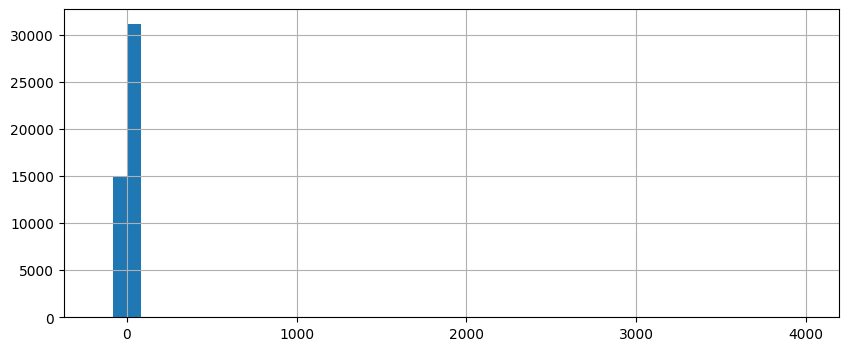

In [ ]:
diff_df.difference.hist(bins=50, figsize=(10, 4));

In [ ]:
diff_df.difference.describe()

,difference
count,46172.00
mean,4.25
std,24.83
min,-165.00
25%,0.00
50%,4.99
75%,6.99
max,3984.99


**Interpretation:** Quartile passen zu plausiblen Versandkosten (0,00 / 4,99 / 6,99). Extremwerte (Min/Max) deuten auf fehlerhafte Daten hin → Ausreißerbehandlung folgt.

## 10. Ausreißer entfernen (IQR-Regel)

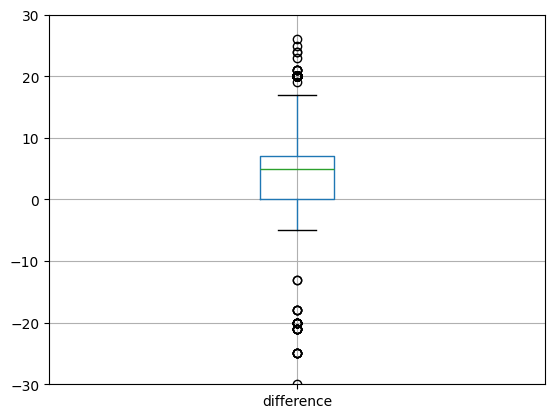

In [ ]:
import matplotlib.pyplot as plt
ax = diff_df.boxplot("difference")
ax.set_ylim(-30, 30)
plt.show()

In [ ]:
Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)
Q1, Q3

(np.float64(0.0), np.float64(6.989999999999981))

In [ ]:
IQR = Q3 - Q1
IQR

np.float64(6.989999999999981)

In [ ]:
Q1 - 1.5 * IQR  # untere Grenze

np.float64(-10.484999999999971)

In [ ]:
Q3 + 1.5 * IQR  # obere Grenze

np.float64(17.47499999999995)

In [ ]:
diff_no_outliers_df = diff_df.loc[
    (diff_df["difference"] >= (Q1 - 1.5 * IQR))
    & (diff_df["difference"] <= (Q3 + 1.5 * IQR)),
    :
]

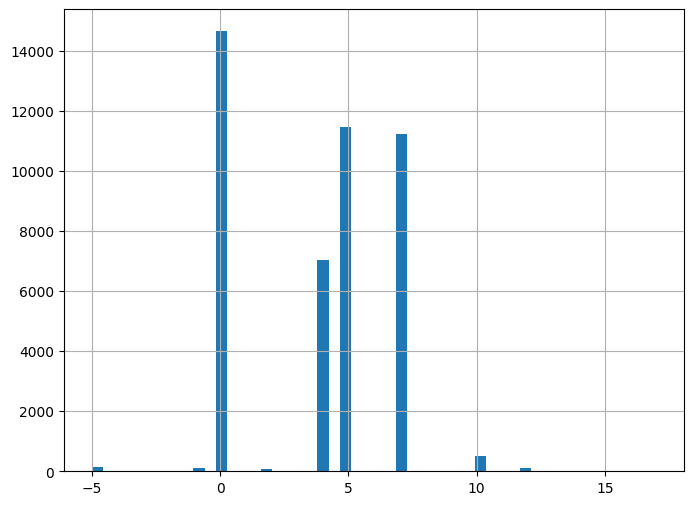

In [ ]:
diff_no_outliers_df.difference.hist(bins=50, figsize=(8, 6));

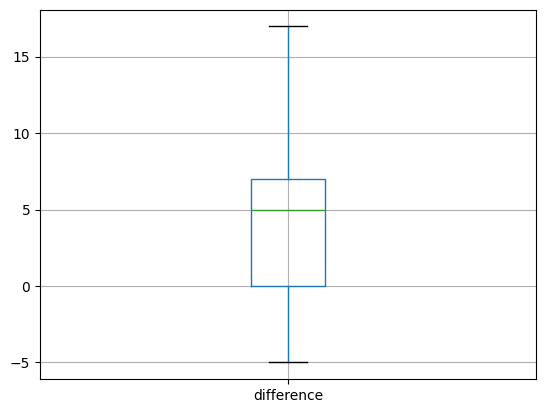

In [ ]:
diff_no_outliers_df.boxplot("difference");

In [ ]:
normal_diff_list = diff_no_outliers_df["order_id"]

In [ ]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(normal_diff_list), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(normal_diff_list), :]

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(45418, 45418)

## 11. Speichern (Abschluss Meilenstein 4)

- Export als `orders_qu.csv`, `orderlines_qu.csv`, `products_qu.csv`,`brands_qu.csv` → Ordner `2.Data/2.Data_cleaned_01/final_CSV_quality/`.

In [ ]:
#Bereinigte Daten speichern in Drive

from google.colab import files

# orders_qu.to_csv("orders_qu.csv", index=False)
# files.download("orders_qu.csv")

# orderlines_qu.to_csv("orderlines_qu.csv", index=False)
# files.download("orderlines_qu.csv")

# products_qu.to_csv("products_qu.csv", index=False)
# files.download("products_qu.csv")

---
# TEIL C — Analyse & Kategorien (Meilenstein 5–6) → Ergebnis: *_analyse

# 03 – Eniac Rabattstrategie: Analyse
**Meilenstein 5–6** (siehe Projektplan)

**Projektziel:** Sind Rabatte für Eniac langfristig vorteilhaft (Position Marketing) oder schädlich für Umsatz und Positionierung (Position Vorstand/Investoren)?

**Entscheidende Frage:** Nimmt der Umsatz mit steigenden Rabatten zu?

**Inhaltsverzeichnis**
1. Import der qualitätsgeprüften Daten (Meilenstein 4)
2. Rabatt berechnen (`discount_percent`)
3. Bestellinformationen ergänzen
4. Kategorien erstellen
5. Zeitraum & Umsatz
6. Saisonale Muster
7. Meistverkaufte Produkte & Umsatz nach Kategorie
8. Rabattanalyse – Kernfrage
9. Zusatzanalysen (Preisempfehlung vs. Verkaufspreis, Bestellwert über Zeit, Produkt-Überschneidung)
10. Zusammenfassung / Entscheidungsgrundlage CEO

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

##1.Import der qualitätsgeprüften Daten (Meilenstein 4)

### 🔗 Brücke aus Teil B — eigene Arbeitskopie erstellen (kein Reimport von Drive)

In [ ]:
orders_analyse = orders_qu.copy()
orderlines_analyse = orderlines_qu.copy()
products_analyse = products_qu.copy()
brands_analyse = brands_qu.copy()

*Hinweis:* Die drei/vier Drive-Links müssen jeweils auf **unterschiedliche** Dateien zeigen (in einer früheren Version zeigten `orders_qu` und `orderlines_qu` versehentlich auf dieselbe Datei).

In [ ]:
orders_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45418 entries, 1 to 226619
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      45418 non-null  int64         
 1   created_date  45418 non-null  datetime64[ns]
 2   total_paid    45418 non-null  float64       
 3   state         45418 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.7+ MB


In [ ]:
orderlines_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60179 entries, 7 to 293661
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                60179 non-null  int64         
 1   id_order          60179 non-null  int64         
 2   product_quantity  60179 non-null  int64         
 3   sku               60179 non-null  object        
 4   unit_price        60179 non-null  float64       
 5   date              60179 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 3.2+ MB


In [ ]:
products_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10534 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          10534 non-null  object 
 1   name         10534 non-null  object 
 2   desc         10534 non-null  object 
 3   price        10534 non-null  float64
 4   promo_price  10534 non-null  object 
 5   in_stock     10534 non-null  int64  
 6   type         10534 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 658.4+ KB


In [ ]:
brands_analyse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


### 1.1 Arbeitskopien erstellen
🔗 **Wichtig:** Ab hier NUR noch mit den `_analyse`-Kopien weiterarbeiten — nicht mit `orders_qu`/`orderlines_qu`/`products_cl` direkt. So bleibt der Meilenstein-4-Datenstand unangetastet, falls ihr am Ende versehentlich mit demselben Dateinamen exportiert.

## 2. Rabatt berechnen (`discount_percent`)

In [ ]:
orderlines_products_analyse = orderlines_analyse.merge(products_analyse, on='sku', how='inner')

# --- RADIKALE BEREINIGUNG FÜR BEIDE SPALTEN ---
for col in ['unit_price', 'price']:
    orderlines_products_analyse[col] = orderlines_products_analyse[col].astype(str).str.strip()
    multi_point_mask = orderlines_products_analyse[col].str.count(r'\.') > 1
    orderlines_products_analyse.loc[multi_point_mask, col] = (
        orderlines_products_analyse.loc[multi_point_mask, col].str.replace('.', '', 1)
    )

    # 3 Nachkommastellen korrigieren (z.B. 5608.689 -> 560.87)
    temp_numeric = pd.to_numeric(orderlines_products_analyse[col], errors='coerce')
    three_decimals_mask = orderlines_products_analyse[col].str.contains(r'\.\d{3}$') & temp_numeric.notna()
    if three_decimals_mask.any():
        orderlines_products_analyse.loc[three_decimals_mask, col] = round(temp_numeric / 10, 2)

# Konvertierung in echte Zahlen
orderlines_products_analyse['unit_price'] = pd.to_numeric(orderlines_products_analyse['unit_price'], errors='coerce')
orderlines_products_analyse['price'] = pd.to_numeric(orderlines_products_analyse['price'], errors='coerce')
orderlines_products_analyse = orderlines_products_analyse.dropna(subset=['unit_price', 'price'])

# --- HIER WIRD DIE FORMEL AUSGEFÜHRT ---
orderlines_products_analyse['discount_percent'] = 100 - (orderlines_products_analyse['unit_price'] * 100 / orderlines_products_analyse['price'])

# --- DIE AUSGABE: Hier machen wir das Ergebnis sichtbar ---
print("--- Die ersten Zeilen mit berechnetem Rabatt ---")
display(orderlines_products_analyse[['sku', 'unit_price', 'price', 'discount_percent']].head(20))

print("\n--- Kurze statistische Übersicht der Rabatte ---")
display(orderlines_products_analyse['discount_percent'].describe())


--- Die ersten Zeilen mit berechnetem Rabatt ---


,sku,unit_price,price,discount_percent
0,OWC0100,47.49,60.99,22.13
1,IOT0014,18.99,22.95,17.25
2,APP0700,72.19,89.00,18.89
3,PAC0929,2565.99,3209.00,20.04
4,CRU0039-A,60.90,76.99,20.90
5,PEB0015,142.49,299.99,52.50
6,BEA0065,256.49,299.95,14.49
7,SAT0010,18.99,29.99,36.68
8,SYN0139,166.24,175.99,5.54
9,LOG0191,142.49,209.00,31.82



--- Kurze statistische Übersicht der Rabatte ---


,discount_percent
count,60179.00
mean,21.91
std,20.22
min,-212.27
25%,8.27
50%,17.15
75%,28.58
max,99.98


**Formel:** Rabatt (%) = 100 − (unit_price × 100 / price)

- Positive Werte = Rabatt gegenüber Listenpreis
- Negative Werte = Verkaufspreis lag über dem aktuell gespeicherten Listenpreis (z. B. Preiserhöhung nach Kauf, oder Datenfehler)

##4.Kategorien erstellen
Ableitung aus `desc`/`name` per Keyword-Regeln, da `type` nur Codes ohne Klartext liefert.

In [ ]:
alle_woerter = products_analyse['name'].fillna('').str.lower().str.split().explode()
worthaeufigkeit = alle_woerter.value_counts()
worthaeufigkeit.head(30)

,count
name,
|,4173
apple,2689
iphone,2042
case,1970
/,1960
pro,1855
-,1538
ram,1351
macbook,1289


In [ ]:
import re

# ============================================================
# 1. Primäre Zuordnung über 'type' (eindeutiger als reines Keyword-Matching)
#    Basis: manuelle Stichprobenprüfung der 30 größten type-Codes
# ============================================================
type_to_category = {
    '5,74E+15': 'Computers (iMac)',
    '1282':     'Computers (MacBook)',
    '12175397': 'Storage & NAS',
    '11865403': 'Accessories & Cables',
    '2158':     'Computers (MacBook)',
    '11935397': 'Storage & NAS',
    '1,02E+12': 'Computers (MacBook)',
    '12635403': 'Accessories & Cables',
    '13835403': 'Accessories & Cables',
    '1,44E+11': 'Services',
    '1364':     'Components (RAM/SSD)',
    '1433':     'Components (RAM/SSD)',
    '12585395': 'Accessories & Cables',
    '1296':     'Monitors',
    '1325':     'Accessories & Cables',
    '5384':     'Audio',
    '12215397': 'Components (RAM/SSD)',
    '5398':     'Audio',
    '57445397': 'Components (RAM/SSD)',
    '1334':     'Network',
    '1229':     'Accessories & Cables',
    '12655397': 'Storage & NAS',
    '2449':     'Wearables',
    '12995397': 'Accessories & Cables',
    '1515':     'Accessories & Cables',
    '13615399': 'Accessories & Cables',
    '1405':     'Tablets',
    '13555403': 'Accessories & Cables',
    # '1298' und '11905404' bewusst NICHT gemappt — Stichproben zeigten gemischte
    # Inhalte ohne eindeutiges Thema. Fallen unten in den Keyword-Fallback.
}

orderlines_products_analyse['category'] = orderlines_products_analyse['type'].map(type_to_category)

# ============================================================
# 2. Fallback über Keywords MIT Wortgrenzen (behebt light/lightning, ram/frame,
#    pen/opening, ios/studios etc. — reines "in text" hatte diese Kollisionen)
# ============================================================
category_rules = [
    ('Computers (MacBook)', ['macbook']),
    ('Computers (iMac)', ['imac']),
    ('Computers (Mac Mini)', ['mac mini']),
    ('Mobile Phones', ['iphone']),
    ('Tablets', ['ipad', 'wacom', 'intuos', 'graphics tablet', 'cintiq']),
    ('Wearables', ['airpods', 'watch', 'fitbit', 'bracelet']),
    ('Audio', ['speaker', 'headphone', 'headphones', 'microphone', 'soundbar']),
    ('Monitors', ['monitor', 'display', 'cinema display']),
    ('Storage & NAS', ['nas', 'synology', 'seagate', 'raid', 'qnap', 'hard drive']),
    ('Components (RAM/SSD)', ['ram', 'ssd', 'memory card', 'sata', 'flash drive', 'pendrive']),
    ('Network', ['router', 'ethernet', 'wifi', 'wi-fi', 'bluetooth', 'airport']),
    ('Smart Home', ['philips hue', 'thermostat', 'homekit', 'motion sensor']),
    ('Drones & Action Cameras', ['gopro', 'drone', 'quadcopter']),
    ('Software', ['photoshop', 'illustrator', 'microsoft office']),
    ('Services', ['repair', 'installation', 'warranty', 'applecare']),
    ('Accessories & Cables', ['case', 'cable', 'adapter', 'charger', 'keyboard',
                              'mouse', 'lightning', 'sleeve', 'stylus']),
]

def categorize_by_keyword(text):
    for category, keywords in category_rules:
        for kw in keywords:
            if re.search(rf'\b{re.escape(kw)}\b', text):
                return category
    return 'Other'

fehlende_maske = orderlines_products_analyse['category'].isna()
name_lower_fallback = orderlines_products_analyse.loc[fehlende_maske, 'desc'].fillna('').str.lower()
orderlines_products_analyse.loc[fehlende_maske, 'category'] = name_lower_fallback.apply(categorize_by_keyword)

# ============================================================
# 3. Kontrolle
# ============================================================
print(orderlines_products_analyse['category'].value_counts())
print('Anteil Other:', round((orderlines_products_analyse['category'] == 'Other').mean() * 100, 1), '%')

category
Accessories & Cables       14438
Mobile Phones              10608
Components (RAM/SSD)        7532
Storage & NAS               7443
Computers (MacBook)         4887
Audio                       3240
Tablets                     2964
Other                       1956
Computers (iMac)            1808
Monitors                    1711
Wearables                   1595
Network                     1168
Smart Home                   345
Services                     311
Computers (Mac Mini)         166
Drones & Action Cameras        7
Name: count, dtype: int64
Anteil Other: 3.3 %


In [ ]:
print(orderlines_products_analyse['category'].value_counts())
print('Anteil Other:', round((orderlines_products_analyse['category']=='Other').mean()*100, 1), '%')

category
Accessories & Cables       14438
Mobile Phones              10608
Components (RAM/SSD)        7532
Storage & NAS               7443
Computers (MacBook)         4887
Audio                       3240
Tablets                     2964
Other                       1956
Computers (iMac)            1808
Monitors                    1711
Wearables                   1595
Network                     1168
Smart Home                   345
Services                     311
Computers (Mac Mini)         166
Drones & Action Cameras        7
Name: count, dtype: int64
Anteil Other: 3.3 %


In [ ]:
other_mask = orderlines_products_analyse['category'] == 'Other'
orderlines_products_analyse.loc[other_mask, :]

,id,id_order,product_quantity,sku,unit_price,date,name,desc,price,promo_price,in_stock,type,discount_percent,category
7,1119155,299564,1,SAT0010,18.99,2017-01-01 02:43:37,Satechi Aluminum Silver Mouse,Aluminum mat with ultra soft non-slip surface ...,29.99,16.992,1,1387,36.68,Other
29,1119328,297809,1,IFX0016,14.24,2017-01-01 12:01:12,iFixit Heavy Duty Suction Cups Pack 2 suction ...,Pack of 2 suction to remove the glass LCD scre...,20.99,199.408,1,14305406,32.16,Other
43,1119490,299710,1,PHI0072,66.49,2017-01-01 14:05:28,Philips Hue bulbs 9.5W White Pack 2 Starter Ki...,Kit 2 bulbs E27 + white light controller Bridge,79.95,649.903,1,11905404,16.84,Other
51,1119547,299742,2,NEA0017,21.84,2017-01-01 15:18:19,Support Netatmo MOODBOARD or Pluviometer,Netatmo support for weather station,24.99,22.99,1,11905404,12.61,Other
92,1119914,299939,1,PHI0072,66.49,2017-01-01 20:25:31,Philips Hue bulbs 9.5W White Pack 2 Starter Ki...,Kit 2 bulbs E27 + white light controller Bridge,79.95,649.903,1,11905404,16.84,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59968,1647418,525632,2,MAC0144,24.99,2018-03-12 17:37:58,Macally Lampcharge Lamp with 4 USB ports,Table lamp with touch control and 4 USB charge...,39.95,249.901,1,11905404,37.45,Other
60080,1648275,526426,1,TAD0001-A,124.97,2018-03-13 13:18:07,Open - Tado Smart Climate Control Intelligent AC,Reconditioned intelligent air conditioning con...,179.00,1.249.739,0,11905404,30.18,Other
60087,1648346,526455,1,MAC0144,24.99,2018-03-13 14:15:13,Macally Lampcharge Lamp with 4 USB ports,Table lamp with touch control and 4 USB charge...,39.95,249.901,1,11905404,37.45,Other
60089,1648365,526466,1,SOF0131,74.99,2018-03-13 14:37:02,Mac Parallels Desktop 13,The easiest and fastest way to run Windows on ...,79.99,749.898,0,1416,6.25,Other


*Hinweis:* Kategorie-Zuordnung ggf. verfeinern, falls `Anteil Other` zu hoch ausfällt (weitere Keywords ergänzen).

##3.Bestellinformationen ergänzen

In [ ]:
orders_orderlines_products_analyse = orders_analyse.merge(
    orderlines_products_analyse, left_on="order_id", right_on="id_order", how="inner"
)
orders_orderlines_products_analyse.shape[0]

60179

In [ ]:
orders_orderlines_products_analyse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60179 entries, 0 to 60178
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          60179 non-null  int64         
 1   created_date      60179 non-null  datetime64[ns]
 2   total_paid        60179 non-null  float64       
 3   state             60179 non-null  object        
 4   id                60179 non-null  int64         
 5   id_order          60179 non-null  int64         
 6   product_quantity  60179 non-null  int64         
 7   sku               60179 non-null  object        
 8   unit_price        60179 non-null  float64       
 9   date              60179 non-null  datetime64[ns]
 10  name              60179 non-null  object        
 11  desc              60179 non-null  object        
 12  price             60179 non-null  float64       
 13  promo_price       60179 non-null  object        
 14  in_stock          6017

*Hinweis:* Status-Filter (`Completed`) ist bereits in Meilenstein 4 angewendet — keine erneute Filterung nötig.

##5.Zeitraum & Umsatz

###5.1Zeitraum des Datensatzes

In [ ]:
orders_analyse.loc[:, "created_date"] = pd.to_datetime(orders_analyse["created_date"])
zeitraum_start = orders_analyse["created_date"].min()
zeitraum_ende = orders_analyse["created_date"].max()
print(f"Zeitraum: {zeitraum_start} bis {zeitraum_ende}")

Zeitraum: 2017-01-01 01:51:47 bis 2018-03-14 12:03:52


###5.2Gesamtumsatz im Zeitraum

In [ ]:
gesamtumsatz = orders_analyse["total_paid"].sum()
print(f"Gesamtumsatz: {gesamtumsatz:.2f}")

Gesamtumsatz: 15364514.33


###5.3Umsatz nach Jahr / Monat

In [ ]:
# --- REPARATUR: Sicherstellen, dass es ein echtes Datum ist ---
orders_analyse["created_date"] = pd.to_datetime(orders_analyse["created_date"])

# Jetzt funktioniert der .dt-Zugriff fehlerfrei
orders_analyse.loc[:, "year"] = orders_analyse["created_date"].dt.year
umsatz_jahr = orders_analyse.groupby("year", as_index=False)["total_paid"].sum()
umsatz_jahr

,year,total_paid
0,2017,11920216.48
1,2018,3444297.85


In [ ]:
orders_analyse.loc[:, "month"] = orders_analyse["created_date"].dt.to_period("M")
umsatz_monat = orders_analyse.groupby("month", as_index=False)["total_paid"].sum()
umsatz_monat

,month,total_paid
0,2017-01,1157930.11
1,2017-02,616113.78
2,2017-03,114599.32
3,2017-04,420213.41
4,2017-05,596554.24
5,2017-06,621297.29
6,2017-07,1010130.62
7,2017-08,710546.18
8,2017-09,847269.93
9,2017-10,1066769.02


In [ ]:
orders_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45418 entries, 1 to 226619
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      45418 non-null  int64         
 1   created_date  45418 non-null  datetime64[ns]
 2   total_paid    45418 non-null  float64       
 3   state         45418 non-null  object        
 4   year          45418 non-null  int32         
 5   month         45418 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(1), period[M](1)
memory usage: 2.3+ MB


In [ ]:
orderlines_analyse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60179 entries, 7 to 293661
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                60179 non-null  int64         
 1   id_order          60179 non-null  int64         
 2   product_quantity  60179 non-null  int64         
 3   sku               60179 non-null  object        
 4   unit_price        60179 non-null  float64       
 5   date              60179 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 3.2+ MB


In [ ]:
orders_orderlines_products_analyse['umsatz'] = (
    orders_orderlines_products_analyse['product_quantity'] * orders_orderlines_products_analyse['unit_price']
)

###8.Rabattanalyse – Kernfrage
**Nimmt der Umsatz mit steigenden Rabatten zu?**

In [ ]:
m = orders_orderlines_products_analyse
m['rabatt_bucket'] = pd.cut(m['discount_percent'], bins=range(0, 110, 10))

In [ ]:
m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60179 entries, 0 to 60178
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          60179 non-null  int64         
 1   created_date      60179 non-null  datetime64[ns]
 2   total_paid        60179 non-null  float64       
 3   state             60179 non-null  object        
 4   id                60179 non-null  int64         
 5   id_order          60179 non-null  int64         
 6   product_quantity  60179 non-null  int64         
 7   sku               60179 non-null  object        
 8   unit_price        60179 non-null  float64       
 9   date              60179 non-null  datetime64[ns]
 10  name              60179 non-null  object        
 11  desc              60179 non-null  object        
 12  price             60179 non-null  float64       
 13  promo_price       60179 non-null  object        
 14  in_stock          6017

In [ ]:
m['rabatt_bucket'].unique()

[(0.0, 10.0], (40.0, 50.0], (20.0, 30.0], (10.0, 20.0], NaN, ..., (90, 100], (80, 90], (60, 70], (50, 60], (70, 80]]
Length: 11
Categories (10, interval[int64, right]): [(0, 10] < (10, 20] < (20, 30] < (30, 40] ... (60, 70] <
                                          (70, 80] < (80, 90] < (90, 100]]

In [ ]:
# from google.colab import files

# orders_analyse.to_csv("orders_analyse.csv", index=False)
# files.download("orders_analyse.csv")

# orderlines_analyse.to_csv("orderlines_analyse.csv", index=False)
# files.download("orderlines_analyse.csv")

# orderlines_products_analyse.to_csv("orderlines_products_merged_analyse.csv", index=False)
# files.download("orderlines_products_merged_analyse.csv")

In [ ]:
sales_df = m.copy()
sales_df = sales_df.drop(columns=['promo_price','id', 'in_stock'])


In [ ]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60179 entries, 0 to 60178
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          60179 non-null  int64         
 1   created_date      60179 non-null  datetime64[ns]
 2   total_paid        60179 non-null  float64       
 3   state             60179 non-null  object        
 4   id_order          60179 non-null  int64         
 5   product_quantity  60179 non-null  int64         
 6   sku               60179 non-null  object        
 7   unit_price        60179 non-null  float64       
 8   date              60179 non-null  datetime64[ns]
 9   name              60179 non-null  object        
 10  desc              60179 non-null  object        
 11  price             60179 non-null  float64       
 12  type              60179 non-null  object        
 13  discount_percent  60179 non-null  float64       
 14  category          6017

In [ ]:
#Bereinigte Daten speichern in Drive

from google.colab import files

#sales_df.to_csv("sales_qu.csv", index=False)
#files.download("sales_qu.csv")


In [ ]:
# url = "https://https://drive.google.com/file/d/140nv_HeQVpfDBcI6mOZAclus6v1GPfNM/view?usp=sharing" # orderlines.csv
# path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
# sales_qu = pd.read_csv(path)

In [ ]:
#sales_df = sales_qu.copy()

# **Daten Visualisirung**

In [ ]:
sales_df['created_date'] =pd.to_datetime(sales_df['created_date'], errors='coerce')
sales_df['date'] =pd.to_datetime(sales_df['date'], errors='coerce')

In [ ]:
sales_df["discount_status"] = sales_df["discount_percent"].apply(
    lambda x: "Discounted" if x > 0 else "No Discount"
)

##Frage 1 – Rabattstatus

In [ ]:
# ----------------------------------------------------------
# Frage 1
# Vergleich des durchschnittlichen Umsatzes von Produkten
# mit und ohne Rabatt.
# ----------------------------------------------------------
sales_df.groupby("discount_status")["umsatz"].mean().round(2)

,umsatz
discount_status,
Discounted,257.75
No Discount,181.69


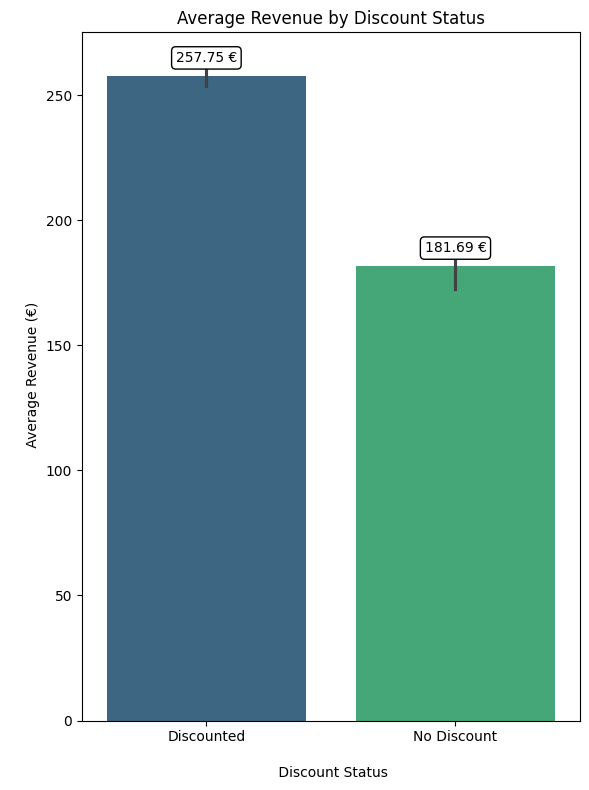

In [161]:
# Visualisierung des durchschnittlichen Umsatzes nach Rabattstatus.
plt.figure(figsize=(6,8))

ax = sns.barplot(
    data=sales_df,
    x="discount_status",
    y="umsatz",
    hue='discount_status',
    palette="viridis"
)

plt.title("Average Revenue by Discount Status")
plt.xlabel("\n Discount Status")
plt.ylabel("\n Average Revenue (€)")
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f €",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )
plt.savefig('charts_01.png', dpi=300, bbox_inches='tight')
plt.show()

# Erkenntnis:
# Das Diagramm zeigt den durchschnittlichen Umsatz
# von rabattierten und nicht rabattierten Produkten.

In [162]:
from google.colab import files
files.download('charts_01.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 2 – Saison (Rabattierte Produkte)

In [ ]:
# ----------------------------------------------------------
# Frage 2
# Vergleich des durchschnittlichen Umsatzes rabattierter
# Produkte zwischen Normal Season und Peak Season.
# ----------------------------------------------------------
sales_df["month"] = sales_df["date"].dt.to_period("M").astype(str)

In [ ]:
sales_df["month"] = sales_df["date"].dt.strftime("%Y-%m")

In [ ]:
sales_count_month = (
    sales_df
    .groupby("month")
    .size()
    .reset_index(name="sales_count")
)

sales_count_month

,month,sales_count
0,2017-01,6636
1,2017-02,2875
2,2017-03,275
3,2017-04,2089
4,2017-05,2445
5,2017-06,2040
6,2017-07,4508
7,2017-08,3008
8,2017-09,2862
9,2017-10,4039


In [ ]:
peak_months = ["2017-11", "2017-12", "2018-01"]

sales_df["season"] = sales_df["month"].apply(
    lambda x: "Peak Season" if x in peak_months else "Normal Season"
)

In [ ]:
discounted_df = sales_df[
    sales_df["discount_status"] == "Discounted"
]

In [ ]:
discounted_df.groupby("season")["umsatz"].mean().round(2)

,umsatz
season,
Normal Season,237.54
Peak Season,288.10


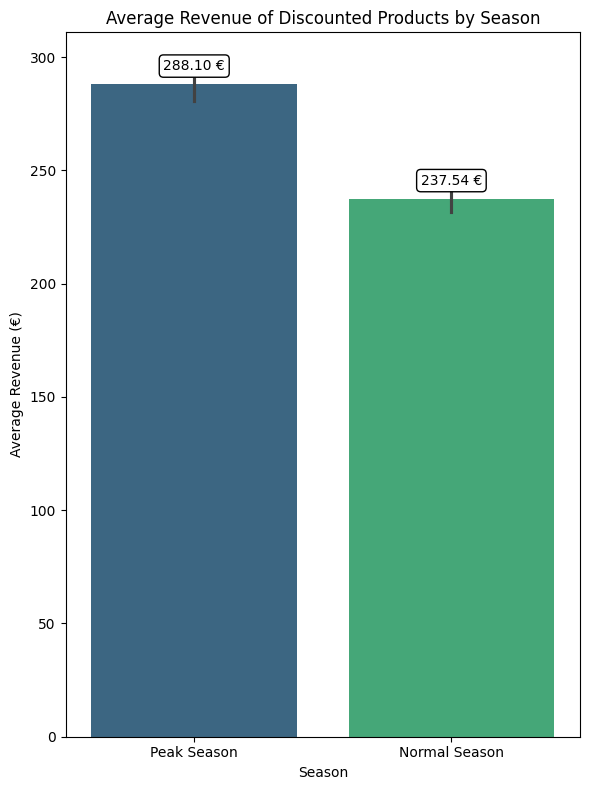

In [165]:
plt.figure(figsize=(6,8))

ax = sns.barplot(
    data=discounted_df,
    x="season",
    y="umsatz",
    hue="season",
    legend=False,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f €",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Average Revenue of Discounted Products by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (€)")

plt.tight_layout()
plt.savefig('charts_02_02.png', dpi=300, bbox_inches='tight')

plt.show()
# Erkenntnis:
# Während der Peak Season erzielen rabattierte Produkte
# einen höheren durchschnittlichen Umsatz.

In [166]:
files.download('charts_02_02.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 3 – Verkaufsmenge nach Saison

In [ ]:
# ----------------------------------------------------------
# Frage 3
# Vergleich der durchschnittlichen Verkaufsmenge
# zwischen den beiden Saisons.
# ----------------------------------------------------------
sales_per_month = (
    discounted_df
    .groupby("month")
    .size()
    .reset_index(name="sales")
)

sales_per_month

,month,sales
0,2017-01,6055
1,2017-02,2603
2,2017-03,230
3,2017-04,1882
4,2017-05,2124
5,2017-06,1787
6,2017-07,4194
7,2017-08,2784
8,2017-09,2598
9,2017-10,3770


In [ ]:
sales_per_month["season"] = sales_per_month["month"].apply(
    lambda x: "Peak Season" if x in peak_months else "Normal Season"
)

In [ ]:
sales_per_month.groupby("season")["sales"].mean().round(2)

,sales
season,
Normal Season,2802.08
Peak Season,7462.67


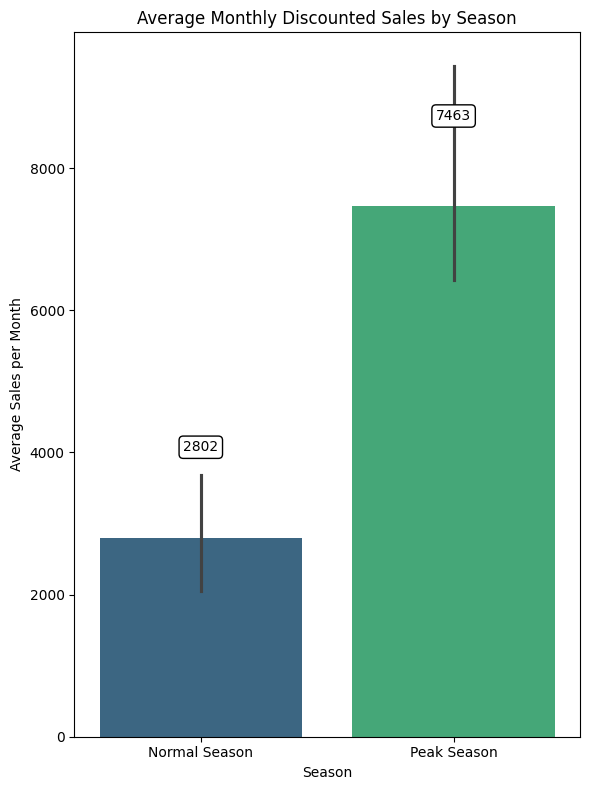

In [163]:
plt.figure(figsize=(6,8))

ax = sns.barplot(
    data=sales_per_month,
    x="season",
    y="sales",
    hue="season",
    legend=False,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=60,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Average Monthly Discounted Sales by Season")
plt.xlabel("Season")
plt.ylabel("Average Sales per Month")
plt.savefig('charts_02_01.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
# Erkenntnis:
# In der Peak Season werden durchschnittlich
# mehr Produkte verkauft.

In [164]:
files.download('charts_02_01.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 4 – Durchschnittlicher Umsatz nach Rabattstufe (Normal Season)

In [ ]:
# ----------------------------------------------------------
# Frage 4
# Durchschnittlicher Umsatz nach Rabattkategorie
# in der Normal Season.
# ----------------------------------------------------------
normal_df = sales_df[sales_df["season"] == "Normal Season"]

In [ ]:
normal_discount = (
    normal_df
    .groupby("rabatt_bucket")["umsatz"]
    .mean()
    .round(2)
    .reset_index()
)

normal_discount

/tmp/ipykernel_1315/481899515.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rabatt_bucket")["umsatz"]


,rabatt_bucket,umsatz
0,"(0, 10]",488.78
1,"(10, 20]",225.89
2,"(20, 30]",170.26
3,"(30, 40]",108.15
4,"(40, 50]",42.15
5,"(50, 60]",38.43
6,"(60, 70]",27.35
7,"(70, 80]",36.91
8,"(80, 90]",27.24
9,"(90, 100]",240.40


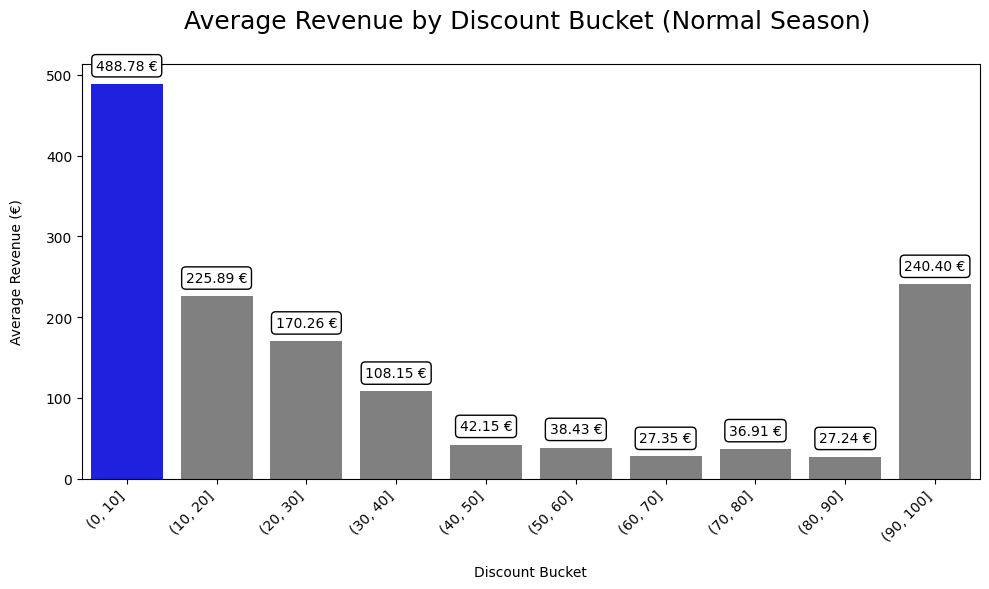

In [167]:
plt.figure(figsize=(10,6))
colors = ['blue' if umsatz > 400 else 'gray' for umsatz in normal_discount['umsatz']]
ax = sns.barplot(
    data=normal_discount,
    x="rabatt_bucket",
    y="umsatz",
    hue="rabatt_bucket",
    legend=False,
    palette=colors
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f €",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Average Revenue by Discount Bucket (Normal Season) \n", fontsize=18)
plt.xlabel("\nDiscount Bucket")
plt.ylabel("Average Revenue (€)\n")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts_03_01.png', dpi=300, bbox_inches='tight')

plt.show()
# Erkenntnis:
# Kleine bis mittlere Rabatte erzielen häufig
# höhere durchschnittliche Umsätze als sehr hohe Rabatte.

In [168]:
files.download('charts_03_01.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 5 – Verkäufe nach Rabattstufe (Normal Season)

In [ ]:
# ----------------------------------------------------------
# Frage 5
# Anzahl der Verkäufe je Rabattkategorie
# in der Normal Season.
# ----------------------------------------------------------
sales_bucket = (
    normal_df
    .groupby("rabatt_bucket")
    .size()
    .reset_index(name="sales")
)

sales_bucket

/tmp/ipykernel_1315/3997523583.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rabatt_bucket")


,rabatt_bucket,sales
0,"(0, 10]",8154
1,"(10, 20]",9753
2,"(20, 30]",6716
3,"(30, 40]",2866
4,"(40, 50]",1878
5,"(50, 60]",1565
6,"(60, 70]",1178
7,"(70, 80]",594
8,"(80, 90]",327
9,"(90, 100]",594


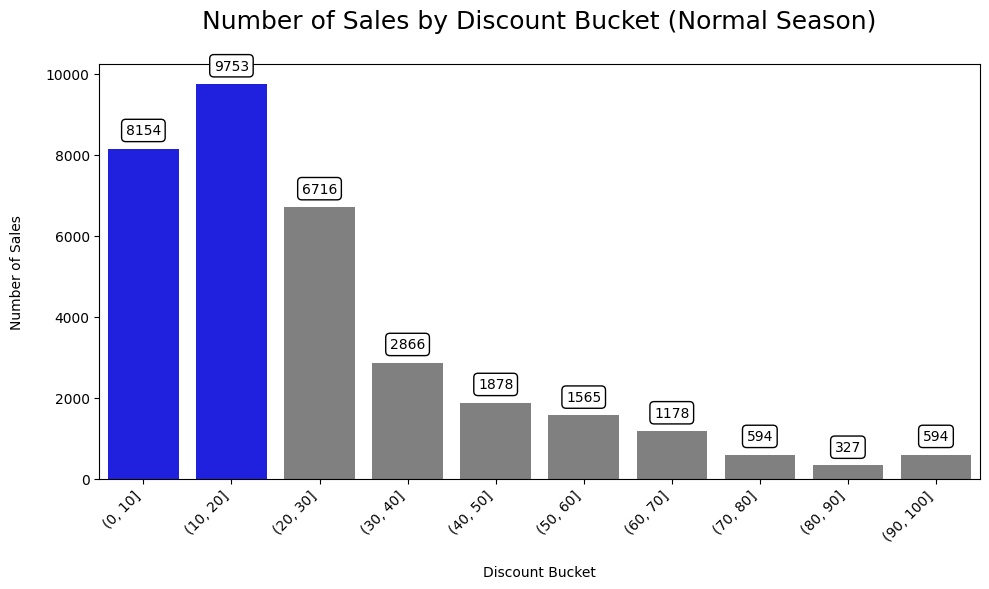

In [169]:
colors = ['blue' if sale > 8000 else 'gray' for sale in sales_bucket['sales']]
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=sales_bucket,
    x="rabatt_bucket",
    y="sales",
    hue="rabatt_bucket",
    legend=False,
    palette=colors
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Number of Sales by Discount Bucket (Normal Season)\n", fontsize=18)
plt.xlabel("\nDiscount Bucket")
plt.ylabel("Number of Sales\n")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts_03_02.png', dpi=300, bbox_inches='tight')

plt.show()
# Erkenntnis:
# Die meisten Verkäufe entfallen auf bestimmte
# Rabattkategorien.

In [170]:
files.download('charts_03_02.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 6 – Durchschnittlicher Umsatz nach Rabattstufe (Peak Season)

In [ ]:
# ----------------------------------------------------------
# Frage 6
# Durchschnittlicher Umsatz nach Rabattkategorie
# in der Peak Season.
# ----------------------------------------------------------
peak_df = sales_df[sales_df["season"] == "Peak Season"]

In [ ]:
peak_discount = (
    peak_df
    .groupby("rabatt_bucket")["umsatz"]
    .mean()
    .round(2)
    .reset_index()
)

peak_discount

/tmp/ipykernel_1315/483958610.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rabatt_bucket")["umsatz"]


,rabatt_bucket,umsatz
0,"(0, 10]",585.09
1,"(10, 20]",288.95
2,"(20, 30]",175.22
3,"(30, 40]",78.03
4,"(40, 50]",42.22
5,"(50, 60]",30.91
6,"(60, 70]",20.36
7,"(70, 80]",23.81
8,"(80, 90]",72.51
9,"(90, 100]",588.47


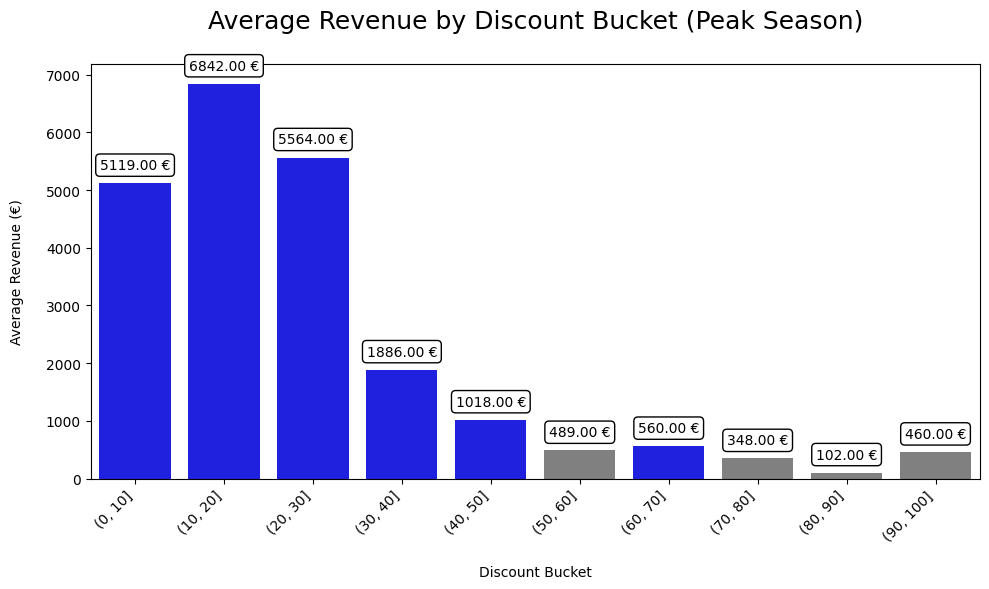

In [171]:
colors = ['blue' if umsatz > 500 else 'gray' for umsatz in peak_discount['umsatz']]
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=peak_discount,
    x="rabatt_bucket",
    y="umsatz",
    color=colors,
    hue="rabatt_bucket",
    legend=False,
    palette=colors
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f €",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Average Revenue by Discount Bucket (Peak Season)\n", fontsize=18)
plt.xlabel("\nDiscount Bucket")
plt.ylabel("Average Revenue (€)\n")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts_04_01.png', dpi=300, bbox_inches='tight')
plt.show()
# Erkenntnis:
# Auch in der Peak Season führen kleine bis mittlere
# Rabatte zu den höchsten Umsätzen.

In [172]:
files.download('charts_04_01.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 7 – Verkäufe nach Rabattstufe (Peak Season)

In [ ]:
# ----------------------------------------------------------
# Frage 7
# Anzahl der Verkäufe je Rabattkategorie
# in der Peak Season.
# ----------------------------------------------------------
peak_df = sales_df[sales_df["season"] == "Peak Season"]

peak_discount = peak_df.groupby(["season", "rabatt_bucket"])["umsatz"].count().reset_index()

peak_discount

/tmp/ipykernel_1315/3419451637.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  peak_discount = peak_df.groupby(["season", "rabatt_bucket"])["umsatz"].count().reset_index()


,season,rabatt_bucket,umsatz
0,Peak Season,"(0, 10]",5119
1,Peak Season,"(10, 20]",6842
2,Peak Season,"(20, 30]",5564
3,Peak Season,"(30, 40]",1886
4,Peak Season,"(40, 50]",1018
5,Peak Season,"(50, 60]",489
6,Peak Season,"(60, 70]",560
7,Peak Season,"(70, 80]",348
8,Peak Season,"(80, 90]",102
9,Peak Season,"(90, 100]",460


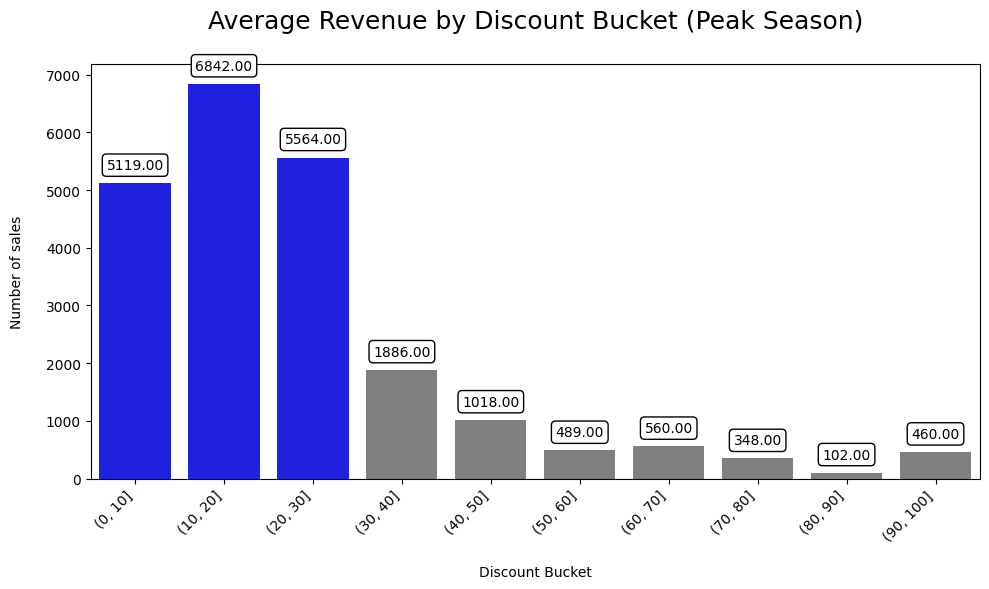

In [174]:
colors = ['blue' if umsatz > 5000 else 'gray' for umsatz in peak_discount['umsatz']]
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=peak_discount,
    x="rabatt_bucket",
    y="umsatz",
    color=colors,
    hue="rabatt_bucket",
    legend=False,
    palette=colors
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Average Revenue by Discount Bucket (Peak Season)\n", fontsize=18)
plt.xlabel("\nDiscount Bucket")
plt.ylabel("Number of sales\n")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts_04_02.png', dpi=300, bbox_inches='tight')

plt.show()
# Erkenntnis:
# Die Verkaufszahlen steigen während der Peak Season
# deutlich an.

In [175]:
files.download('charts_04_02.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 8 – Top 10 Produkte

In [ ]:
# ----------------------------------------------------------
# Frage 8
# Top 10 Produkte nach Gesamtumsatz
# während der Peak Season.
# ----------------------------------------------------------
peak_df = sales_df[sales_df["season"] == "Peak Season"]

top_product = (
    peak_df.groupby("name")
    .agg(
        total_revenue=("umsatz", "sum"),
        avg_discount=("discount_percent", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .reset_index()
)



In [ ]:
top_products = (
    peak_df.groupby("name", as_index=False)
    .agg(
        total_revenue=("umsatz","sum"),
        avg_discount=("discount_percent","mean")
    )
    .nlargest(10, "total_revenue")
)



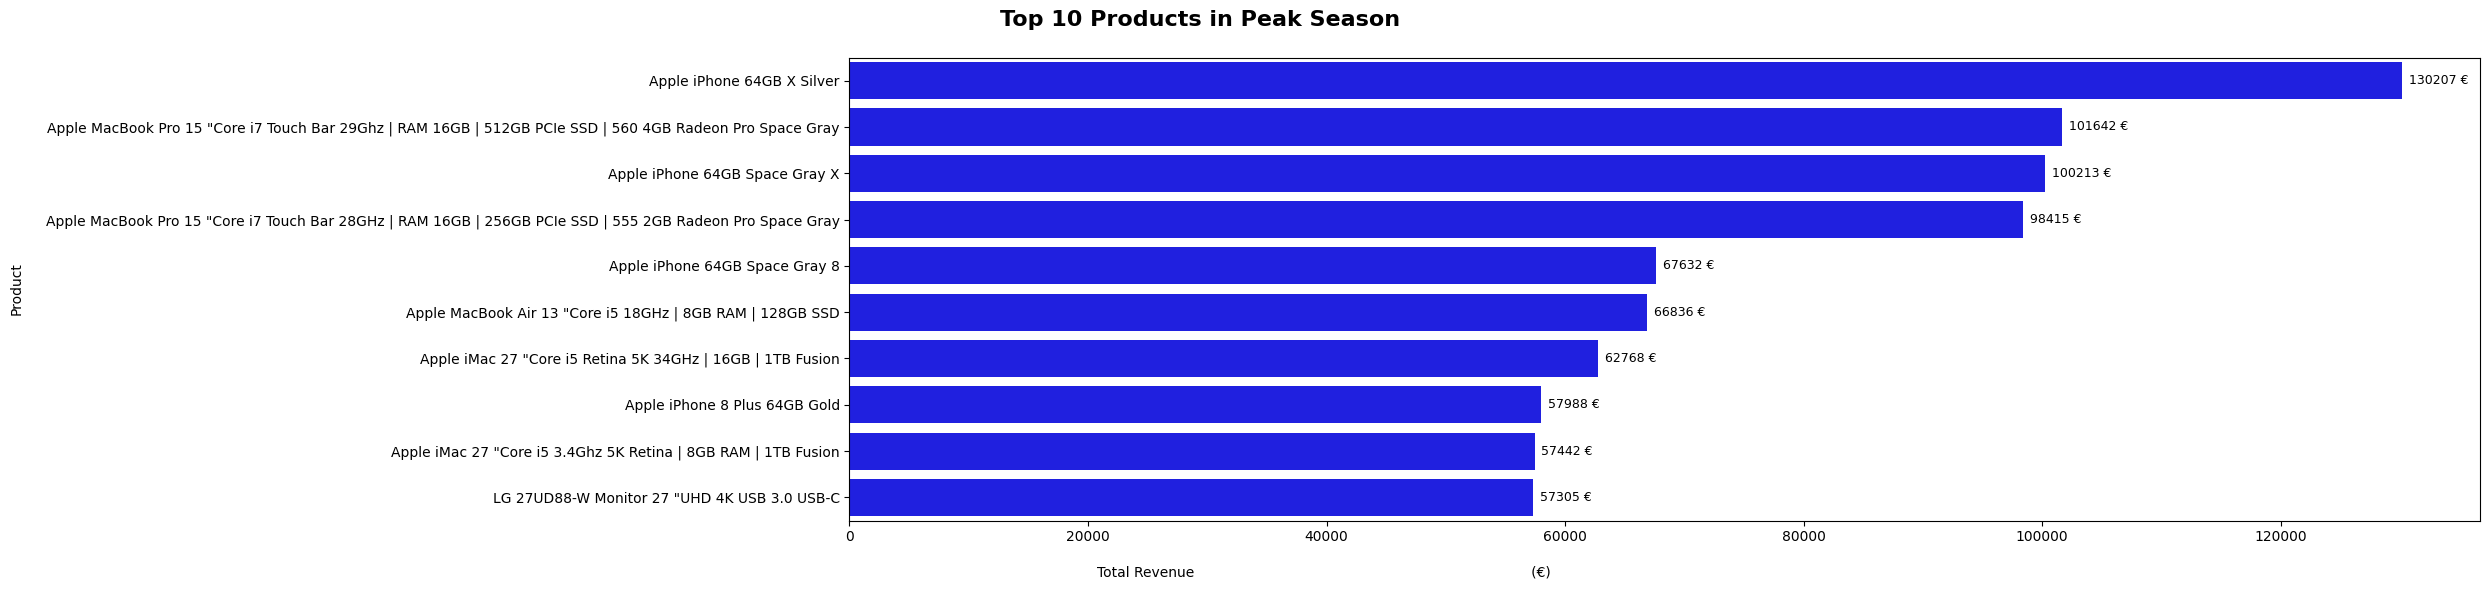

In [177]:
plt.figure(figsize=(25,6))

ax = sns.barplot(
    data=top_products,
    x="total_revenue",
    y="name",
    color='blue',
    dodge=False,
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f €",
        padding=5,
        fontsize=9
    )

plt.title(
    "Top 10 Products in Peak Season                                                                                                                        \n",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("\nTotal Revenue                                                                             (€)                                                                                                                                                            ")
plt.ylabel("Product\n")

plt.tight_layout()
plt.savefig('charts_05.png', dpi=300, bbox_inches='tight')

plt.show()
# Erkenntnis:
# Die umsatzstärksten Produkte erreichen hohe Umsätze,
# ohne dass dafür die höchsten Rabatte erforderlich sind.

In [178]:
files.download('charts_05.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



Wie kann die Datenerfassung verbessert werden?

Beobachtungen
Einige Datensätze enthalten fehlende oder unvollständige Informationen.
Es fehlen wichtige Merkmale wie Kundeninformationen oder Marketingkampagnen.
Saisonale Ereignisse (z. B. Black Friday oder Weihnachten) sind nicht direkt im Datensatz gekennzeichnet.
Produktkategorien könnten weiter standardisiert werden.
Empfehlungen
Einheitliche Produktkategorien verwenden.
Saison- und Kampagneninformationen direkt speichern.
Kundendaten und Marketingkanäle ergänzen.
Regelmäßige Qualitätskontrollen der Daten durchführen.
Fehlende Werte frühzeitig erkennen und vermeiden.
Fazit

Eine bessere Datenqualität ermöglicht genauere Analysen und unterstützt fundierte Geschäftsentscheidungen.

Produktklassifizierung und Verbesserung der Datenerfassung
Empfohlene Produktklassifizierung

Um Berichte und Analysen zu vereinfachen, empfehlen wir folgende Produktkategorien:

Smartphones
Laptops
Desktop-PCs
Speichergeräte
Computerkomponenten
Zubehör
Sonstige Elektronik
Vorteile
Bessere Übersicht über das Produktsortiment
Einfachere Erstellung von Berichten
Schnellere Analyse der Verkaufsleistung
Unterstützung fundierter Geschäftsentscheidungen
Verbesserung der Datenerfassung
Einheitliche Produktkategorien verwenden.
Verkaufsaktionen (z. B. Black Friday oder Weihnachten) erfassen.
Kundensegmente dokumentieren.
Produktkosten und Gewinnmargen speichern.
Fehlende oder fehlerhafte Daten regelmäßig überprüfen und bereinigen.